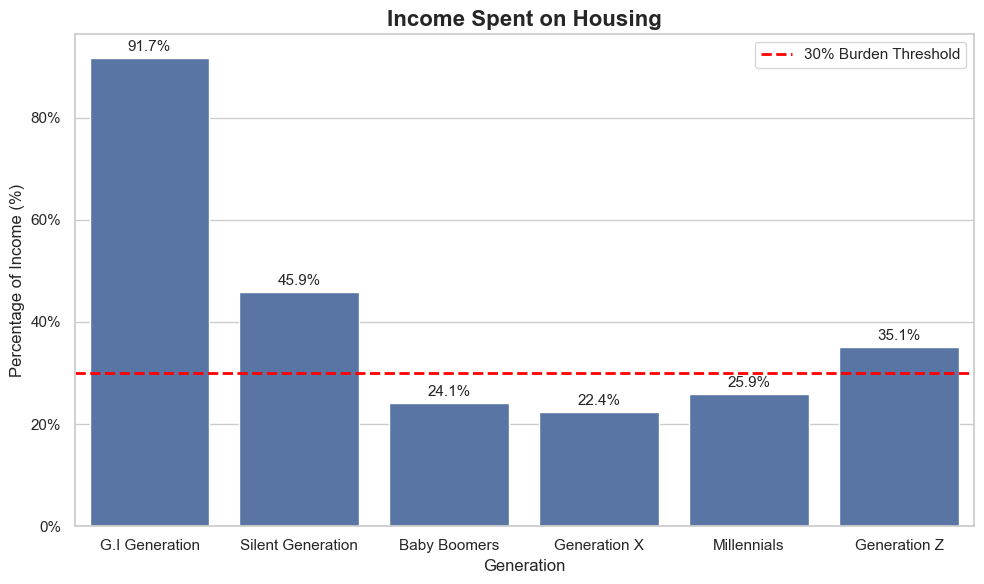

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid")
df = pd.read_csv('MERGED_GENERATIONS.csv')

sns.set_theme(style="whitegrid")

gen_order = ['G.I Generation', 'Silent Generation', 'Baby Boomers', 'Generation X', 'Millennials', 'Generation Z']

df_working_age = df[df['Generation'].isin(gen_order)].copy()

df_working_age['Burdened_Pct'] = df_working_age['Housing_Cost_Ratio'] * 100
gen_ratio = df_working_age.groupby('Generation')['Burdened_Pct'].median().reindex(gen_order).reset_index()

fig2, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=gen_ratio, x='Generation', y='Burdened_Pct', ax=ax)

ax.axhline(30, color='red', linestyle='--', linewidth=2, label='30% Burden Threshold')

plt.title('Income Spent on Housing', fontsize=16, fontweight='bold')
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Percentage of Income (%)', fontsize=12)

ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', padding=3, fontsize=11)

plt.legend()
fig2.tight_layout()
plt.savefig('Generational_Burden.png')
plt.show()

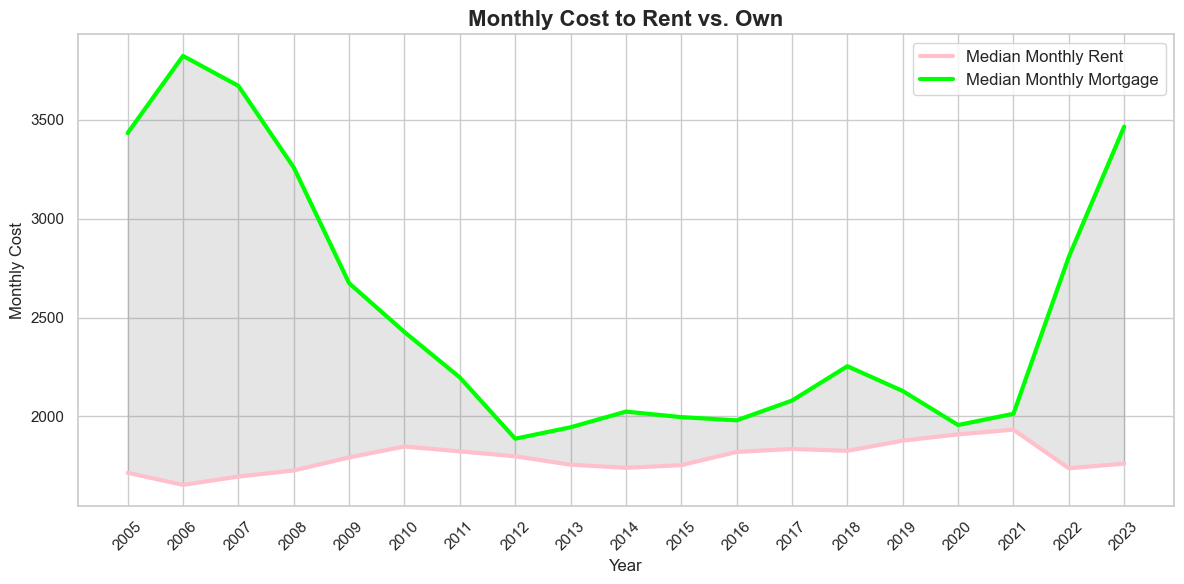

In [53]:
yearly_costs = df.groupby('Year')[['Monthly_Rent', 'Monthly_Mortgage']].median().reset_index()

fig3, ax3 = plt.subplots(figsize=(12, 6))

plt.plot(yearly_costs['Year'], yearly_costs['Monthly_Rent'], color='pink', linewidth=3, label='Median Monthly Rent')
plt.plot(yearly_costs['Year'], yearly_costs['Monthly_Mortgage'], color='lime', linewidth=3, label='Median Monthly Mortgage')

plt.title('Monthly Cost to Rent vs. Own', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Monthly Cost', fontsize=12)
plt.xticks(yearly_costs['Year'], rotation=45)

plt.fill_between(yearly_costs['Year'], yearly_costs['Monthly_Rent'], yearly_costs['Monthly_Mortgage'], color='gray', alpha=0.2)

plt.legend(fontsize=12)
fig3.tight_layout()
plt.savefig('Rent_to_Own.png')
plt.show()

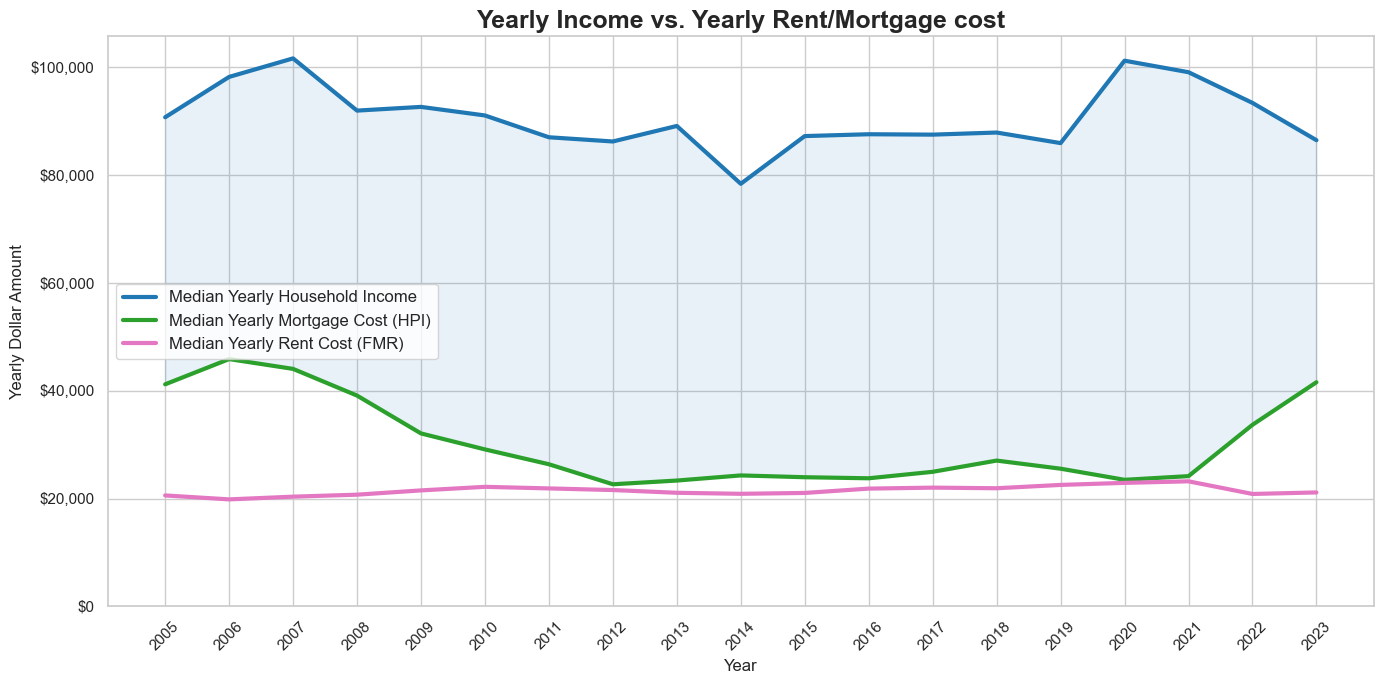

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid")

yearly_data = df.groupby('Year')[['Adjusted_HH_Income', 'Monthly_Rent', 'Monthly_Mortgage']].median().reset_index()

yearly_data['Yearly_Rent'] = yearly_data['Monthly_Rent'] * 12
yearly_data['Yearly_Mortgage'] = yearly_data['Monthly_Mortgage'] * 12


fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(yearly_data['Year'], yearly_data['Adjusted_HH_Income'], color='tab:blue', linewidth=3, label='Median Yearly Household Income')
ax.plot(yearly_data['Year'], yearly_data['Yearly_Mortgage'], color='tab:green', linewidth=3, label='Median Yearly Mortgage Cost (HPI)')
ax.plot(yearly_data['Year'], yearly_data['Yearly_Rent'], color='tab:pink', linewidth=3, label='Median Yearly Rent Cost (FMR)')

ax.fill_between(yearly_data['Year'], yearly_data['Adjusted_HH_Income'], yearly_data['Yearly_Mortgage'], color='tab:blue', alpha=0.1)

plt.title('Yearly Income vs. Yearly Rent/Mortgage cost', fontsize=18, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Yearly Dollar Amount', fontsize=12)

formatter = ticker.StrMethodFormatter('${x:,.0f}')
ax.yaxis.set_major_formatter(formatter)

plt.xticks(yearly_data['Year'], rotation=45)
ax.set_ylim(bottom=0)
plt.legend(fontsize=12, loc='center left')
fig.tight_layout()

# Save and show
plt.savefig('Rent_and_Mortgage_to_Income.png')
plt.show()


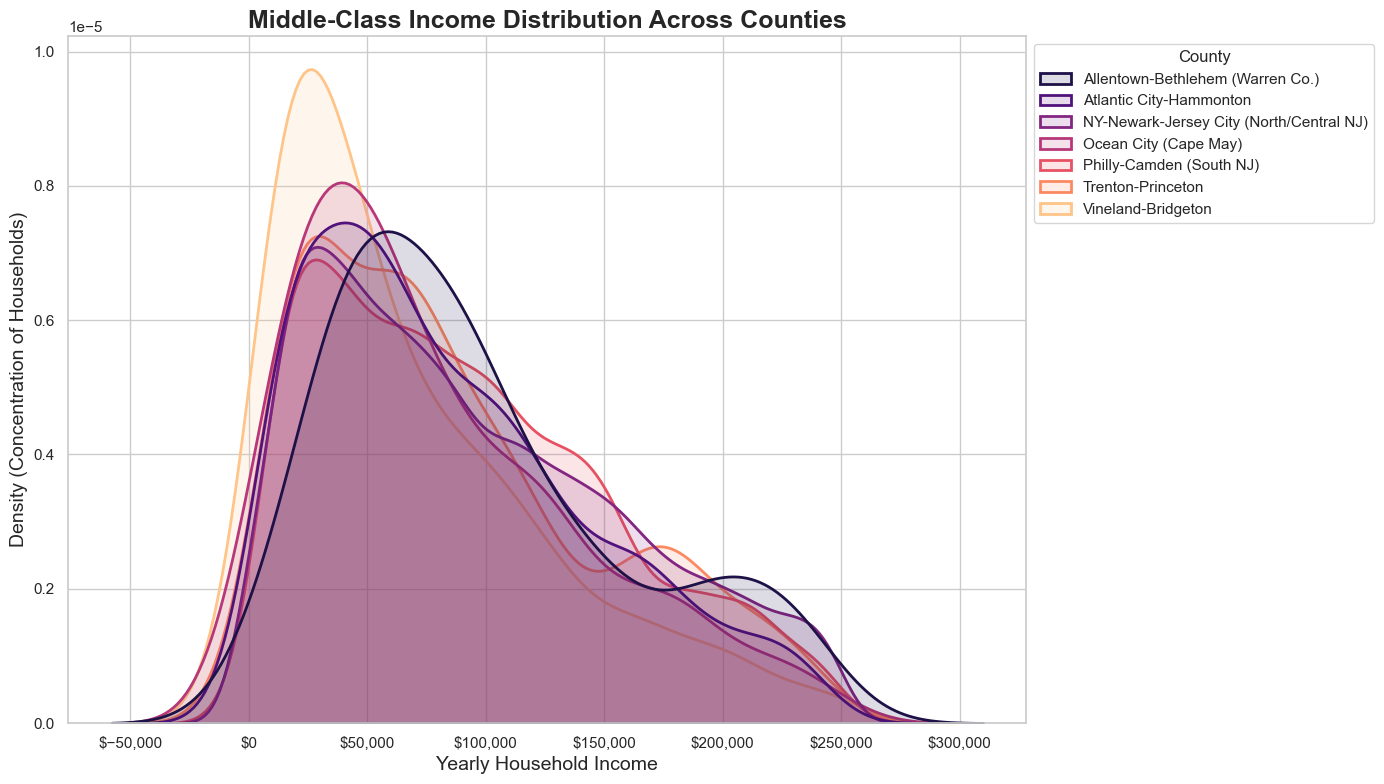

In [55]:
sns.set_theme(style="whitegrid")

cbsa_mapping = {
    0: 'Ocean City (Cape May)',
    10900: 'Allentown-Bethlehem (Warren Co.)',
    12100: 'Atlantic City-Hammonton',
    35620: 'NY-Newark-Jersey City (North/Central NJ)',
    36140: 'Ocean City (Cape May)',
    37980: 'Philly-Camden (South NJ)',
    45940: 'Trenton-Princeton',
    47220: 'Vineland-Bridgeton'
}

df['Region_Name'] = df['CBSA'].map(cbsa_mapping)

max_income_to_plot = 250000
df_plot = df[df['Adjusted_HH_Income'] <= max_income_to_plot]

fig, ax = plt.subplots(figsize=(14, 8))

sns.kdeplot(
    data=df_plot, x='Adjusted_HH_Income', hue='Region_Name', 
    common_norm=False, fill=True, alpha=0.15,        
    linewidth=2, palette="magma"    
)

plt.title('Middle-Class Income Distribution Across Counties', fontsize=18, fontweight='bold')
plt.xlabel('Yearly Household Income', fontsize=14)
plt.ylabel('Density (Concentration of Households)', fontsize=14)

formatter = ticker.StrMethodFormatter('${x:,.0f}')
ax.xaxis.set_major_formatter(formatter)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='County')
fig.tight_layout()

plt.savefig('Income_to_Density.png')
plt.show()


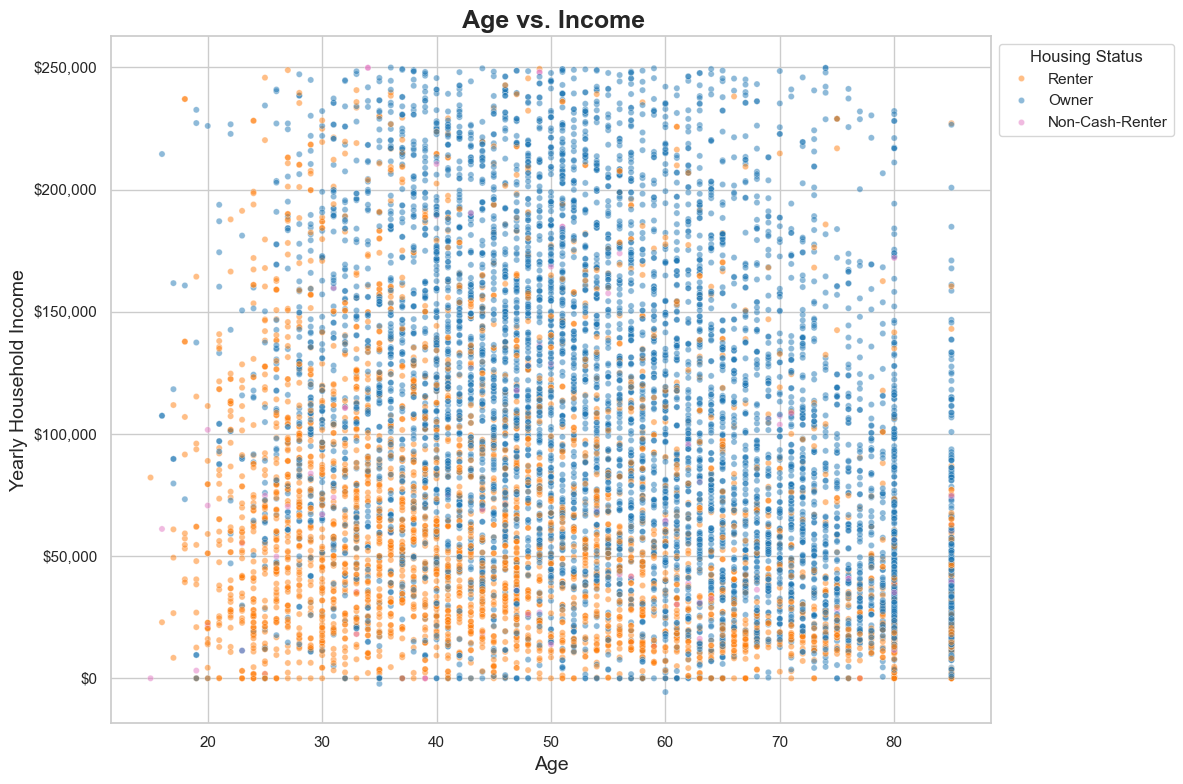

In [56]:

sns.set_theme(style="whitegrid")

tenure_mapping = {1: 'Owner', 2: 'Renter', 3: 'Non-Cash-Renter'}
df['Tenure_Label'] = df['Tenure'].map(tenure_mapping).fillna(df['Tenure'])

max_income_to_plot = 250000
df_filtered = df[df['Adjusted_HH_Income'] <= max_income_to_plot]

n_samples = min(10000, len(df_filtered))
df_sample = df_filtered.sample(n=n_samples, random_state=42)

fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=df_sample, x='Age', y='Adjusted_HH_Income', 
    hue='Tenure_Label', palette={'Owner': 'tab:blue', 'Renter': 'tab:orange', 'Non-Cash-Renter' : 'tab:pink'},
    alpha=0.5, s=20,  ax=ax
)

plt.title(' Age vs. Income', fontsize=18, fontweight='bold')
plt.xlabel('Age', fontsize=14)
plt.ylabel('Yearly Household Income', fontsize=14)

formatter = ticker.StrMethodFormatter('${x:,.0f}')
ax.yaxis.set_major_formatter(formatter)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='Housing Status')
fig.tight_layout()

plt.savefig('Age_to_Income_Scatter.png')
plt.show()

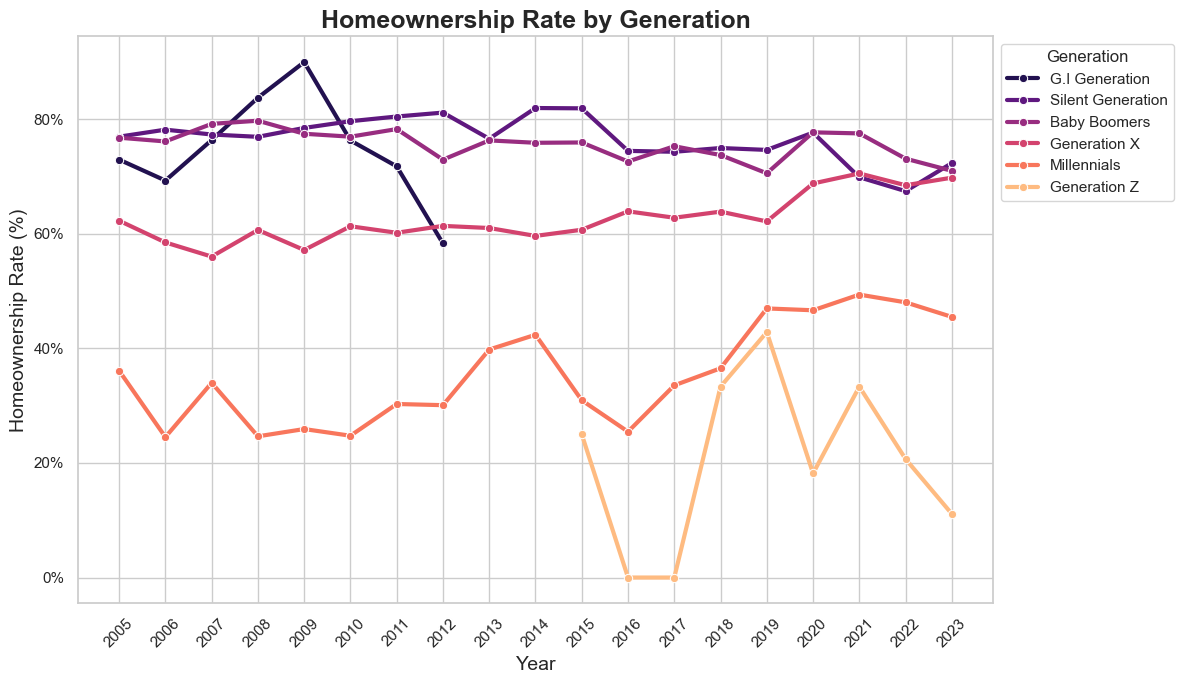

In [57]:
sns.set_theme(style="whitegrid")

gen_order = ['G.I Generation', 'Silent Generation', 'Baby Boomers', 'Generation X', 'Millennials', 'Generation Z']
df_gen = df[df['Generation'].isin(gen_order)].copy()

df_gen['Is_Owner'] = df_gen['Tenure'].apply(lambda x: 1 if str(x) == '1' or x == 'Owner' else 0)

ownership_rates = df_gen.groupby(['Year', 'Generation'])['Is_Owner'].mean().reset_index()

ownership_rates['Ownership_Rate'] = ownership_rates['Is_Owner'] * 100


fig, ax = plt.subplots(figsize=(12, 7))

sns.lineplot(
    data=ownership_rates, x='Year', y='Ownership_Rate',
    hue='Generation', hue_order=gen_order, marker='o',            
    linewidth=3, palette='magma', ax=ax
)

plt.title('Homeownership Rate by Generation', fontsize=18, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Homeownership Rate (%)', fontsize=14)

ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
plt.xticks(ownership_rates['Year'].unique(), rotation=45)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='Generation')
fig.tight_layout()

# Save and Show
plt.savefig('Homeownership_to_Generation.png')
plt.show()

C:\Users\sioti\AppData\Local\Temp\ipykernel_17024\1634499784.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


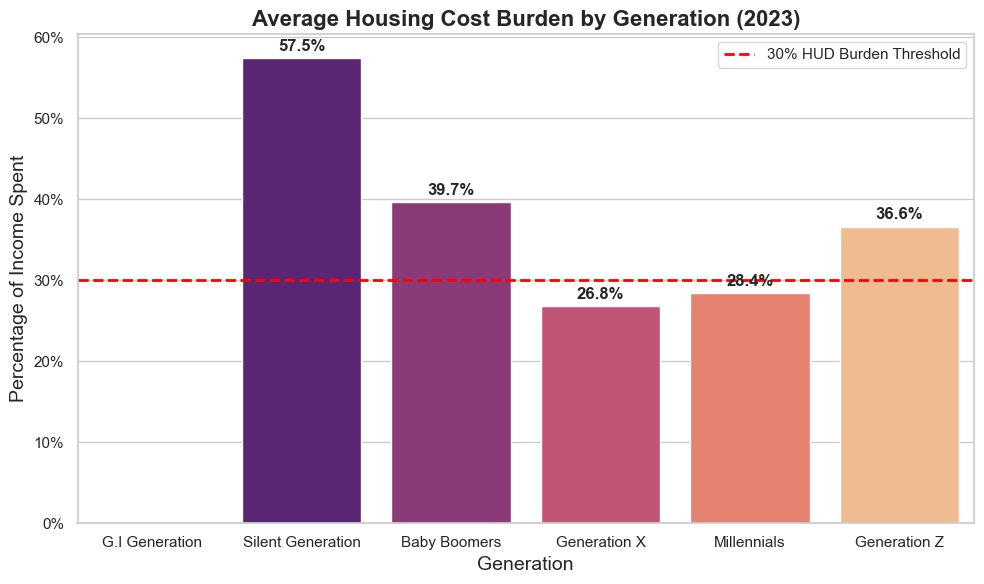

In [58]:
sns.set_theme(style="whitegrid")

df_2023 = df[df['Year'] == 2023].copy()

gen_order = ['G.I Generation', 'Silent Generation', 'Baby Boomers', 'Generation X', 'Millennials', 'Generation Z']
df_2023 = df_2023[df_2023['Generation'].isin(gen_order)].copy()

df_2023['Burden_Pct'] = df_2023['Housing_Cost_Ratio'] * 100

burden_2023 = df_2023.groupby('Generation')['Burden_Pct'].median().reindex(gen_order).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=burden_2023, x='Generation', y='Burden_Pct', palette='magma', ax=ax
)

ax.axhline(30, color='red', linestyle='--', linewidth=2, label='30% HUD Burden Threshold')

plt.title('Average Housing Cost Burden by Generation (2023)', fontsize=16, fontweight='bold')
plt.xlabel('Generation', fontsize=14)
plt.ylabel('Percentage of Income Spent', fontsize=14)

ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

for i in ax.containers:

    ax.bar_label(i, fmt='%.1f%%', padding=3, fontsize=12, fontweight='bold')


plt.legend(loc='upper right')
fig.tight_layout()

plt.savefig('Housing_Burden_2023.png')
plt.show()